In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 

In [2]:
df = pd.read_csv("../data/raw/data1.csv")

In [3]:
df.head()

,diseases,anxiety and nervousness,depression,shortness of breath,depressive or psychotic symptoms,sharp chest pain,dizziness,insomnia,abnormal involuntary movements,chest tightness,...,stuttering or stammering,problems with orgasm,nose deformity,lump over jaw,sore in nose,hip weakness,back swelling,ankle stiffness or tightness,ankle weakness,neck weakness
0,panic disorder,1,0,1,1,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
1,panic disorder,0,0,1,1,0,1,1,0,0,...,0,0,0,0,0,0,0,0,0,0
2,panic disorder,1,1,1,1,0,1,1,0,0,...,0,0,0,0,0,0,0,0,0,0
3,panic disorder,1,0,0,1,0,1,1,1,0,...,0,0,0,0,0,0,0,0,0,0
4,panic disorder,1,1,0,0,0,0,1,1,1,...,0,0,0,0,0,0,0,0,0,0


In [4]:
print("Rows: ",df.shape[0])
print("Columns: ",df.shape[1])

Rows:  246945
Columns:  378


In [5]:
df.columns.tolist()

['diseases',
 'anxiety and nervousness',
 'depression',
 'shortness of breath',
 'depressive or psychotic symptoms',
 'sharp chest pain',
 'dizziness',
 'insomnia',
 'abnormal involuntary movements',
 'chest tightness',
 'palpitations',
 'irregular heartbeat',
 'breathing fast',
 'hoarse voice',
 'sore throat',
 'difficulty speaking',
 'cough',
 'nasal congestion',
 'throat swelling',
 'diminished hearing',
 'lump in throat',
 'throat feels tight',
 'difficulty in swallowing',
 'skin swelling',
 'retention of urine',
 'groin mass',
 'leg pain',
 'hip pain',
 'suprapubic pain',
 'blood in stool',
 'lack of growth',
 'emotional symptoms',
 'elbow weakness',
 'back weakness',
 'pus in sputum',
 'symptoms of the scrotum and testes',
 'swelling of scrotum',
 'pain in testicles',
 'flatulence',
 'pus draining from ear',
 'jaundice',
 'mass in scrotum',
 'white discharge from eye',
 'irritable infant',
 'abusing alcohol',
 'fainting',
 'hostile behavior',
 'drug abuse',
 'sharp abdominal pain

In [6]:
target = "diseases"
X = df.drop(columns = target)
y = df[target]
print("Featurse:", X.shape[1])
print("Target:" , y.name)

Featurse: 377
Target: diseases


In [7]:
df.dtypes.value_counts()

int64    377
str        1
Name: count, dtype: int64

In [8]:
df.isnull().sum().value_counts()

0    378
Name: count, dtype: int64

In [9]:
print("Number of unique diseases: ",df[target].nunique())

Number of unique diseases:  773


In [10]:
disease_counts = df[target].value_counts()
disease_counts.head(20)

diseases
cystitis                          1219
vulvodynia                        1218
nose disorder                     1218
complex regional pain syndrome    1217
spondylosis                       1216
hypoglycemia                      1215
conjunctivitis due to allergy     1215
vaginal cyst                      1215
esophagitis                       1215
peripheral nerve disorder         1215
gastrointestinal hemorrhage       1214
diverticulitis                    1214
acute bronchitis                  1213
infectious gastroenteritis        1212
pneumonia                         1212
fungal infection of the hair      1212
sprain or strain                  1212
spontaneous abortion              1212
gout                              1211
marijuana abuse                   1210
Name: count, dtype: int64

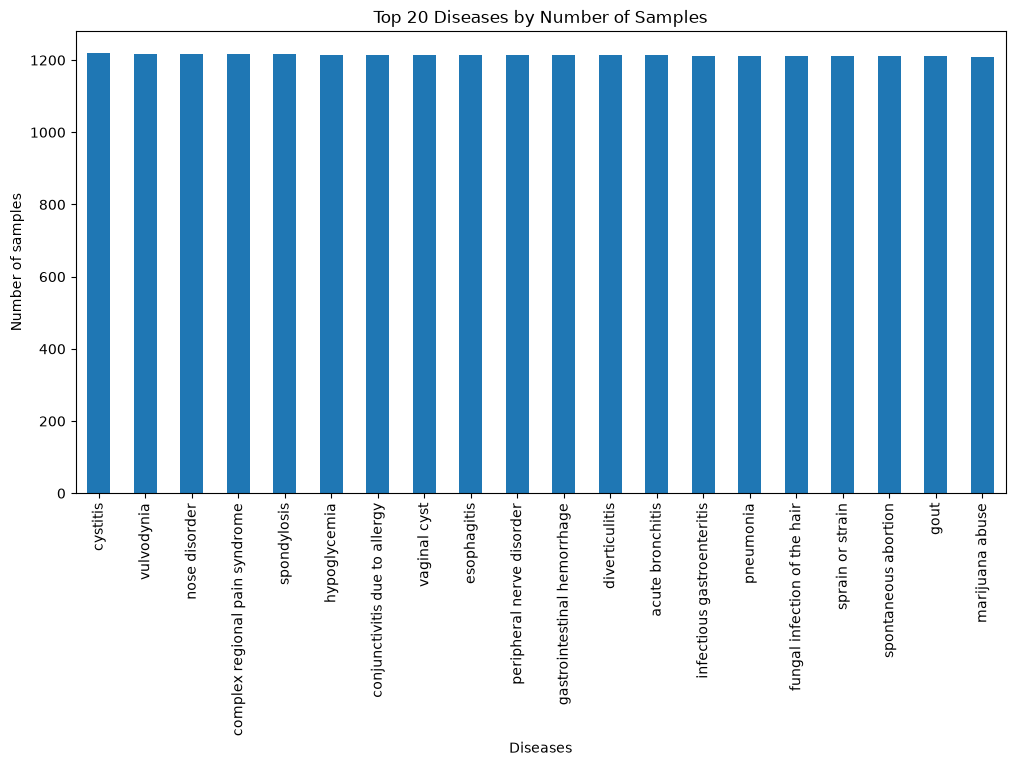

In [11]:
plt.figure(figsize = (12,6))
disease_counts.head(20).plot(kind = "bar")

plt.title("Top 20 Diseases by Number of Samples")
plt.xlabel("Diseases")
plt.ylabel("Number of samples")
plt.xticks(rotation = 90)
plt.show()

In [12]:
disease_counts.describe()

count     773.000000
mean      319.463131
std       351.691549
min         1.000000
25%        30.000000
50%       168.000000
75%       505.000000
max      1219.000000
Name: count, dtype: float64

In [13]:
print("Minimum samples per disease: ",disease_counts.min())
print("Maximum samples per disease: ",disease_counts.max())
print("Mean samples per disease: ",disease_counts.mean())
print("Median samples per disease: ",disease_counts.median())

Minimum samples per disease:  1
Maximum samples per disease:  1219
Mean samples per disease:  319.46313065976716
Median samples per disease:  168.0


In [14]:
symptom_count = X.sum(axis = 1)
symptom_count.describe()

count    246945.000000
mean          5.332851
std           1.640610
min           1.000000
25%           4.000000
50%           5.000000
75%           6.000000
max          12.000000
dtype: float64

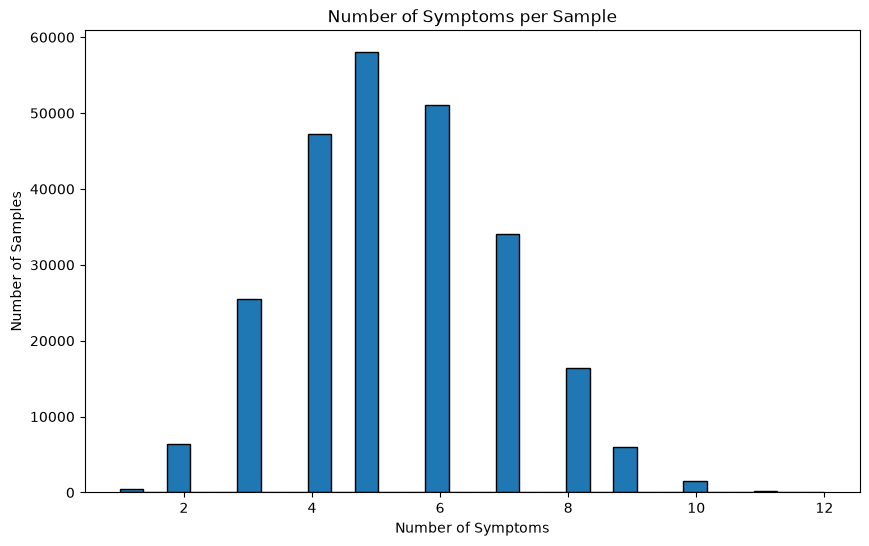

In [15]:
plt.figure(figsize = (10, 6))
plt.hist(symptom_count, bins = 30, edgecolor = "black")
plt.title("Number of Symptoms per Sample")
plt.xlabel("Number of Symptoms")
plt.ylabel("Number of Samples")
plt.show()

In [16]:
unique_values = set(X.values.flatten())
unique_values

{np.int64(0), np.int64(1)}

In [17]:
non_binary_columns = [
    col for col in X.columns
    if not set(X[col].dropna().unique()).issubset({0, 1})
]
print("Non-binary columns: ", non_binary_columns)

Non-binary columns:  []


In [18]:
duplicate_count = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicate_count}")
duplicate_percentage = duplicate_count / len(df) * 100
print(f"Duplicate percentage: {duplicate_percentage:.2f}%")

Number of duplicate rows: 57298
Duplicate percentage: 23.20%


In [19]:
X_duplicates = X.duplicated(keep = False)
print("Rows with duplicate symptom patterns: ",X_duplicates.sum())

Rows with duplicate symptom patterns:  121344


In [20]:
duplicate_symptoms = df[X_duplicates].sort_values(by = X.columns.tolist())
duplicate_symptoms.head()

,diseases,anxiety and nervousness,depression,shortness of breath,depressive or psychotic symptoms,sharp chest pain,dizziness,insomnia,abnormal involuntary movements,chest tightness,...,stuttering or stammering,problems with orgasm,nose deformity,lump over jaw,sore in nose,hip weakness,back swelling,ankle stiffness or tightness,ankle weakness,neck weakness
204771,gynecomastia,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
218878,fibroadenoma,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
56046,allergy,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
77309,food allergy,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
99697,itching of unknown cause,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [21]:
unique_symptom_patterns = X.drop_duplicates().shape[0]
print("Total samples:", len(X))
print("Unique symptoms patterns:", unique_symptom_patterns)
print("Duplicate symptom patterns:", len(X) - unique_symptom_patterns)

Total samples: 246945
Unique symptoms patterns: 169888
Duplicate symptom patterns: 77057


In [22]:
pattern_disease_count = (
    df.groupby(X.columns.tolist())['diseases'].nunique()
)

In [23]:
ambiguous_patterns = pattern_disease_count[pattern_disease_count > 1]
print("Ambiguous symptom patterns:", len(ambiguous_patterns))

Ambiguous symptom patterns: 12634


In [24]:
ambiguous_patterns.value_counts().sort_index()

diseases
2     8914
3     2181
4      762
5      360
6      184
7       99
8       50
9       30
10      14
11       8
12       8
13       6
14       9
15       2
17       1
19       1
20       1
21       1
22       1
24       1
26       1
Name: count, dtype: int64

In [25]:
print("Maximum diseases for one symptom pattern:", pattern_disease_count.max())

Maximum diseases for one symptom pattern: 26


In [26]:
pattern_counts = X.value_counts()
pattern_counts.head(10)

anxiety and nervousness  depression  shortness of breath  depressive or psychotic symptoms  sharp chest pain  dizziness  insomnia  abnormal involuntary movements  chest tightness  palpitations  irregular heartbeat  breathing fast  hoarse voice  sore throat  difficulty speaking  cough  nasal congestion  throat swelling  diminished hearing  lump in throat  throat feels tight  difficulty in swallowing  skin swelling  retention of urine  groin mass  leg pain  hip pain  suprapubic pain  blood in stool  lack of growth  emotional symptoms  elbow weakness  back weakness  pus in sputum  symptoms of the scrotum and testes  swelling of scrotum  pain in testicles  flatulence  pus draining from ear  jaundice  mass in scrotum  white discharge from eye  irritable infant  abusing alcohol  fainting  hostile behavior  drug abuse  sharp abdominal pain  feeling ill  vomiting  headache  nausea  diarrhea  vaginal itching  vaginal dryness  painful urination  involuntary urination  pain during intercourse  fr

In [27]:
disease_symptom_pattern = (
    df.groupby("diseases")[X.columns.tolist()].first()
)

In [28]:
duplicate_disease_profile = disease_symptom_pattern[
    disease_symptom_pattern.duplicated(keep = False)
]
duplicate_disease_profile.shape

(17, 377)

In [29]:
duplicate_disease_profile.index.tolist()

['acute fatty liver of pregnancy (aflp)',
 'dislocation of the knee',
 'dislocation of the patella',
 'fetal alcohol syndrome',
 'fracture of the leg',
 'heart contusion',
 'hirschsprung disease',
 'hypertrophic obstructive cardiomyopathy (hocm)',
 'insulin overdose',
 'kaposi sarcoma',
 'necrotizing fasciitis',
 'open wound of the finger',
 'open wound of the hand',
 'otosclerosis',
 'presbyacusis',
 'septic arthritis',
 'wernicke korsakoff syndrome']

In [30]:
symptoms_per_disease = (
    df.groupby("diseases")[X.columns.tolist()].max().sum(axis = 1)
)
symptoms_per_disease.describe()

count    773.000000
mean       6.971539
std        2.923767
min        2.000000
25%        5.000000
50%        7.000000
75%        9.000000
max       12.000000
dtype: float64

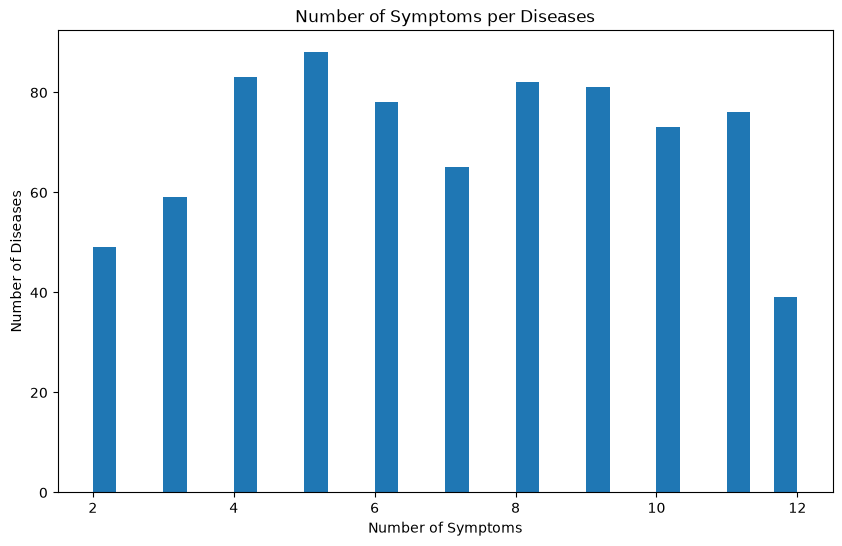

In [31]:
plt.figure(figsize = (10, 6))
plt.hist(symptoms_per_disease, bins = 30)
plt.title("Number of Symptoms per Diseases")
plt.xlabel("Number of Symptoms")
plt.ylabel("Number of Diseases")
plt.show()

In [32]:
symptoms_per_disease.sort_values(ascending = False).head(15)

diseases
acute bronchiolitis                   12
acute bronchitis                      12
benign prostatic hyperplasia (bph)    12
arthritis of the hip                  12
hypoglycemia                          12
infectious gastroenteritis            12
liver disease                         12
cholecystitis                         12
injury to the leg                     12
injury to the arm                     12
temporary or benign blood in urine    12
pneumonia                             12
noninfectious gastroenteritis         12
fungal infection of the hair          12
complex regional pain syndrome        12
dtype: int64

In [33]:
symptom_frequency = X.sum().sort_values(ascending = False)
symptom_frequency.head(20)

sharp abdominal pain                32307
vomiting                            27874
headache                            24719
cough                               24296
sharp chest pain                    24016
nausea                              23687
back pain                           21809
shortness of breath                 21346
fever                               20394
dizziness                           17272
abnormal appearing skin             16425
nasal congestion                    16200
leg pain                            16189
skin swelling                       15165
depressive or psychotic symptoms    15064
lower abdominal pain                14936
sore throat                         14005
burning abdominal pain              12981
skin rash                           12375
skin lesion                         12340
dtype: int64

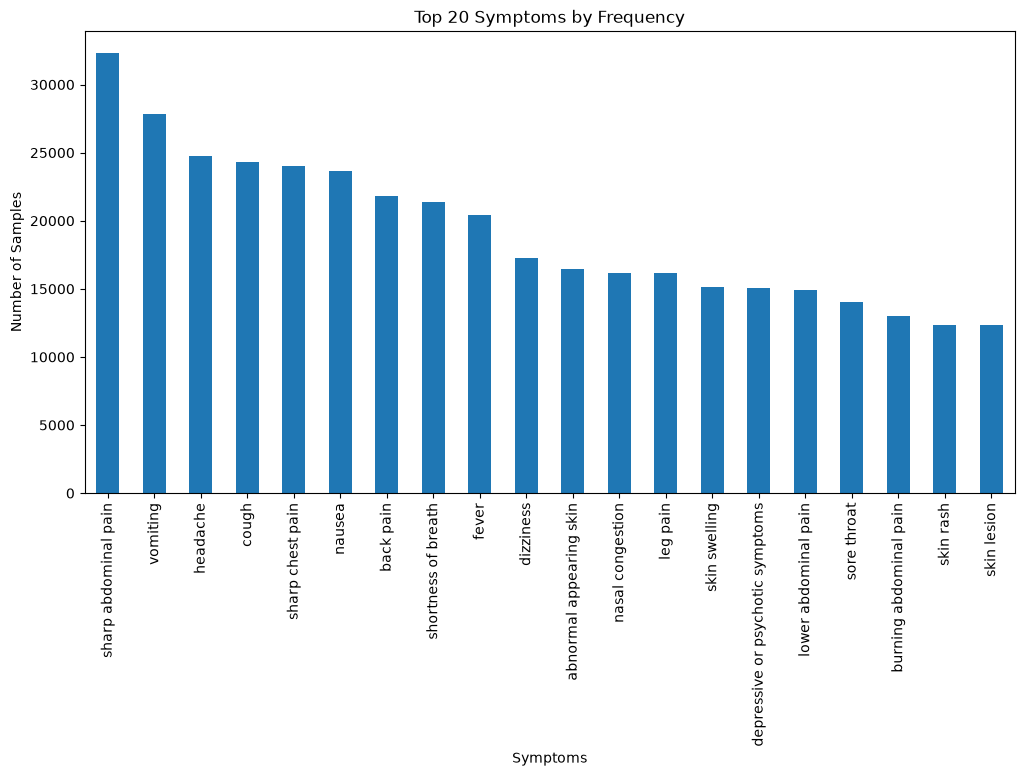

In [34]:
plt.figure(figsize = (12, 6))
symptom_frequency.head(20).plot(kind = "bar")
plt.title("Top 20 Symptoms by Frequency")
plt.xlabel("Symptoms")
plt.ylabel("Number of Samples")
plt.xticks(rotation = 90)
plt.show()

In [35]:
print("Total rows:", len(X))
print("unique symptom pattern:", X.drop_duplicates().shape[0])
print("Repeated rows:",X.duplicated().sum())

Total rows: 246945
unique symptom pattern: 169888
Repeated rows: 77057


In [36]:
unique_patterns = X.drop_duplicates().shape[0]
print(f"Unique pattern percentage: {unique_patterns / len(X) * 100:.2f}%")

Unique pattern percentage: 68.80%


In [37]:
duplicate_rows = df[df.duplicated(keep = False)]
print("Rows involved in repeated full rows:", len(duplicate_rows))
print("Unique repeated symptom patterns:", duplicate_rows.drop_duplicates().shape[0])


Rows involved in repeated full rows: 94067
Unique repeated symptom patterns: 36769


In [38]:
repeated_patterns = pattern_counts[pattern_counts > 1]
print("Repeated symptom patterns:", len(repeated_patterns))

Repeated symptom patterns: 44287


In [39]:
ambiguous_repeated_patterns = pattern_disease_count[(pattern_disease_count > 1) & (pattern_disease_count.index.isin(repeated_patterns.index))]
print(
    "Repeated patterns associated with multiple diseases:",
    len(ambiguous_repeated_patterns)
)

Repeated patterns associated with multiple diseases: 12634


In [40]:
ambiguous_example = (pattern_disease_count[pattern_disease_count > 1].sort_values(ascending = False).head(1))
ambiguous_example

anxiety and nervousness  depression  shortness of breath  depressive or psychotic symptoms  sharp chest pain  dizziness  insomnia  abnormal involuntary movements  chest tightness  palpitations  irregular heartbeat  breathing fast  hoarse voice  sore throat  difficulty speaking  cough  nasal congestion  throat swelling  diminished hearing  lump in throat  throat feels tight  difficulty in swallowing  skin swelling  retention of urine  groin mass  leg pain  hip pain  suprapubic pain  blood in stool  lack of growth  emotional symptoms  elbow weakness  back weakness  pus in sputum  symptoms of the scrotum and testes  swelling of scrotum  pain in testicles  flatulence  pus draining from ear  jaundice  mass in scrotum  white discharge from eye  irritable infant  abusing alcohol  fainting  hostile behavior  drug abuse  sharp abdominal pain  feeling ill  vomiting  headache  nausea  diarrhea  vaginal itching  vaginal dryness  painful urination  involuntary urination  pain during intercourse  fr

In [41]:
example_pattern = ambiguous_example.index[0]
present_symptoms = X.columns[np.array(example_pattern) == 1]
print("Symptom in this pattern:")
print(present_symptoms.tolist())

Symptom in this pattern:
['sharp abdominal pain']


In [42]:
example_rows = df[(X == example_pattern).all(axis = 1)]
print(example_rows["diseases"].value_counts())

diseases
threatened pregnancy                    2
pyelonephritis                          1
problem during pregnancy                1
peritonitis                             1
nonalcoholic liver disease (nash)       1
esophageal cancer                       1
colonic polyp                           1
vulvodynia                              1
hirschsprung disease                    1
diverticulosis                          1
vaginal cyst                            1
rectal disorder                         1
cervicitis                              1
ovarian cancer                          1
pancreatic cancer                       1
chlamydia                               1
idiopathic irregular menstrual cycle    1
cholecystitis                           1
hemorrhoids                             1
chronic constipation                    1
idiopathic painful menstruation         1
idiopathic infrequent menstruation      1
appendicitis                            1
spontaneous abortion     